# Planetary Energy Balance: Radiative Equilibrium Temperature

`blackbody.py`'s `equilibrium_temperature` computes a planet's
radiative-equilibrium temperature from flux balance: absorbed stellar
power (Stefan-Boltzmann-derived, via the same `spectral_radiance`
validated in `Validation.ipynb`) equals emitted blackbody power. This
notebook checks that prediction against the four terrestrial planets'
*actual* measured mean temperatures:

- Mercury and Mars have essentially no atmosphere (or a very thin one)
  -- the bare-rock (no-greenhouse) prediction should closely match their
  actual temperature.
- Earth's real atmosphere traps some outgoing infrared -- the bare-rock
  prediction should undershoot Earth's actual ~288 K by roughly the
  textbook "33 K greenhouse warming" figure.
- Venus's thick CO2 atmosphere causes a runaway greenhouse effect -- the
  bare-rock/actual gap should be dramatically larger than Earth's, even
  though Venus's higher albedo (reflecting more sunlight) would
  otherwise make it *cooler* than Mercury in the bare-rock prediction.

Distances and actual mean temperatures are from NASA's NSSDCA Planetary
Fact Sheet; Bond albedos are commonly-cited literature values (they
vary by a few percent across sources depending on measurement
wavelength/method -- Mercury 0.088, Venus ~0.76, Earth ~0.306, Mars
~0.25); solar luminosity is the IAU 2015 nominal value.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as const

import blackbody as bb

os.makedirs('media', exist_ok=True)

L_sun = 3.828e26  # W, IAU 2015 nominal solar luminosity
AU = const.au     # m, exact IAU-defined astronomical unit

# NASA NSSDCA Planetary Fact Sheet (distance, actual mean temperature);
# Bond albedo from commonly-cited literature values (see markdown above)
planets = {
    'Mercury': {'distance_AU': 0.387, 'albedo': 0.088, 'T_actual': 440.0},
    'Venus':   {'distance_AU': 0.723, 'albedo': 0.76,  'T_actual': 737.0},
    'Earth':   {'distance_AU': 1.000, 'albedo': 0.306, 'T_actual': 288.0},
    'Mars':    {'distance_AU': 1.524, 'albedo': 0.25,  'T_actual': 208.0},
}

## Bare-rock (no-greenhouse) predictions vs. actual temperatures

In [2]:
# Sanity check: greenhouse=0 should reduce exactly to the plain flux-balance
# (bare-rock) result -- confirm before relying on it below.
T_direct = bb.equilibrium_temperature(L_sun, 1.0 * AU, albedo=0.3, greenhouse=0.0)
flux = L_sun / (4 * np.pi * (1.0 * AU)**2)
T_manual = (flux * 0.7 / (4 * const.sigma))**0.25
assert np.isclose(T_direct, T_manual, rtol=1e-12), 'greenhouse=0 should exactly match the plain flux-balance formula'
print(f'sanity check: equilibrium_temperature(greenhouse=0) = {T_direct:.4f} K, '
      f'manual flux-balance calculation = {T_manual:.4f} K -- match.\n')

print(f'{"Planet":8s}  {"distance (AU)":>13s}  {"T_bare (K)":>11s}  {"T_actual (K)":>13s}  {"gap (K)":>8s}')
for name, p in planets.items():
    T_bare = bb.equilibrium_temperature(L_sun, p['distance_AU'] * AU, albedo=p['albedo'])
    p['T_bare'] = T_bare
    gap = p['T_actual'] - T_bare
    print(f'{name:8s}  {p["distance_AU"]:13.3f}  {T_bare:11.1f}  {p["T_actual"]:13.1f}  {gap:8.1f}')

# Mercury and Mars have essentially no atmosphere -- the bare-rock
# prediction should be close to their actual temperature
for name in ['Mercury', 'Mars']:
    rel_err = abs(planets[name]['T_bare'] - planets[name]['T_actual']) / planets[name]['T_actual']
    assert rel_err < 0.05, f'{name} (thin/no atmosphere) should match its bare-rock prediction closely'
print('\nPASS: Mercury and Mars (negligible atmospheres) match their bare-rock predictions to <5%.')

# Earth's real greenhouse effect should show up as a gap in the classic
# ~25-40 K range (the textbook figure is 288-255=33 K)
earth_gap = planets['Earth']['T_actual'] - planets['Earth']['T_bare']
assert 25 < earth_gap < 40, 'Earth\'s bare-rock/actual gap should be near the textbook ~33 K greenhouse figure'
print(f"PASS: Earth's bare-rock prediction undershoots its actual temperature by {earth_gap:.1f} K, "
      f"matching the textbook ~33 K greenhouse-warming figure.")

# Venus's runaway greenhouse effect should dwarf Earth's -- despite
# Venus's much higher albedo (which by itself would make its bare-rock
# prediction *cooler* than Mercury's)
venus_gap = planets['Venus']['T_actual'] - planets['Venus']['T_bare']
assert venus_gap > 5 * earth_gap, "Venus's bare-rock/actual gap should dwarf Earth's (runaway greenhouse)"
print(f"PASS: Venus's gap ({venus_gap:.1f} K) is {venus_gap / earth_gap:.1f}x Earth's ({earth_gap:.1f} K) -- "
      f"the runaway-greenhouse signature, even though Venus's higher albedo alone would predict a "
      f"*cooler* bare-rock temperature than Mercury's ({planets['Venus']['T_bare']:.1f} K vs "
      f"{planets['Mercury']['T_bare']:.1f} K).")

sanity check: equilibrium_temperature(greenhouse=0) = 254.5859 K, manual flux-balance calculation = 254.5859 K -- match.

Planet    distance (AU)   T_bare (K)   T_actual (K)   gap (K)
Mercury           0.387        437.2          440.0       2.8
Venus             0.723        229.1          737.0     507.9
Earth             1.000        254.0          288.0      34.0
Mars              1.524        209.8          208.0      -1.8

PASS: Mercury and Mars (negligible atmospheres) match their bare-rock predictions to <5%.
PASS: Earth's bare-rock prediction undershoots its actual temperature by 34.0 K, matching the textbook ~33 K greenhouse-warming figure.
PASS: Venus's gap (507.9 K) is 15.0x Earth's (34.0 K) -- the runaway-greenhouse signature, even though Venus's higher albedo alone would predict a *cooler* bare-rock temperature than Mercury's (229.1 K vs 437.2 K).


## Implied greenhouse effect: does it order sensibly with real atmospheric thickness?

Planet     implied greenhouse
Mercury                0.0250
Venus                  0.9907
Earth                  0.3946
Mars                  -0.0353

PASS: implied greenhouse parameter increases in the physically expected order (Mars < Mercury < Earth < Venus), matching real atmospheric thickness/opacity -- Mars and Mercury (thin/no atmosphere) near zero, Earth a modest 0.39, Venus's thick CO2 atmosphere an extreme 0.9907.


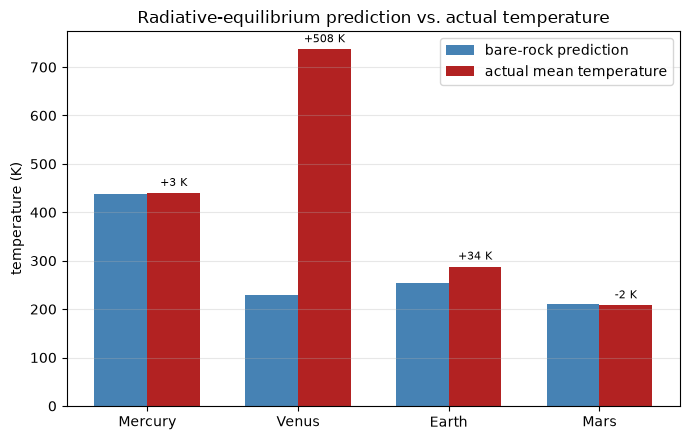

In [3]:
# Back out the single-parameter greenhouse correction each planet's
# *actual* temperature implies (inverting equilibrium_temperature's
# T^4 = T_bare^4/(1-greenhouse) relation), and check it orders sensibly
# with each planet's real atmospheric thickness.
print(f'{"Planet":8s}  {"implied greenhouse":>19s}')
for name, p in planets.items():
    greenhouse = 1 - (p['T_bare'] / p['T_actual'])**4
    p['greenhouse'] = greenhouse
    print(f'{name:8s}  {greenhouse:19.4f}')

order = ['Mars', 'Mercury', 'Earth', 'Venus']
values = [planets[n]['greenhouse'] for n in order]
assert values == sorted(values), 'implied greenhouse parameter should increase with real atmospheric thickness'
print(f'\nPASS: implied greenhouse parameter increases in the physically expected order '
      f'({" < ".join(order)}), matching real atmospheric thickness/opacity -- '
      f'Mars and Mercury (thin/no atmosphere) near zero, Earth a modest {planets["Earth"]["greenhouse"]:.2f}, '
      f'Venus\'s thick CO2 atmosphere an extreme {planets["Venus"]["greenhouse"]:.4f}.')

fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(planets.keys())
x = np.arange(len(names))
width = 0.35
ax.bar(x - width / 2, [planets[n]['T_bare'] for n in names], width, label='bare-rock prediction', color='steelblue')
ax.bar(x + width / 2, [planets[n]['T_actual'] for n in names], width, label='actual mean temperature', color='firebrick')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('temperature (K)')
ax.set_title('Radiative-equilibrium prediction vs. actual temperature')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for i, n in enumerate(names):
    gap = planets[n]['T_actual'] - planets[n]['T_bare']
    ax.annotate(f'{gap:+.0f} K', (x[i] + width / 2, planets[n]['T_actual']),
                textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)
fig.tight_layout()
fig.savefig('media/planetary_energy_balance.png', dpi=150, bbox_inches='tight')
plt.show()